# Assignment 19: K-Nearest Neighbors (K-NN) Classifier

**Objective**: Understand and apply the K-Nearest Neighbors classification algorithm using the Iris Dataset.

## Overview
In this exercise, we will:
1. Load and explore the Iris Dataset.
2. Visualize the data.
3. Split the data into training and testing sets.
4. Train a K-NN Classifier with $K=5$.
5. Evaluate the model using accuracy score and confusion matrix.
6. Discuss the choice of $K$ and the role of Cross-Validation.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

%matplotlib inline

## 1. Load and Explore Data
We will use the classic Iris dataset, which contains measurements for 150 iris flowers from three different species.

In [10]:
# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Map target integers to flower names
df['flower_name'] = df.target.apply(lambda x: iris.target_names[x])

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Visualization
Let's visualize the data to see how the classes are separated. We'll plot Sepal Length vs Sepal Width.

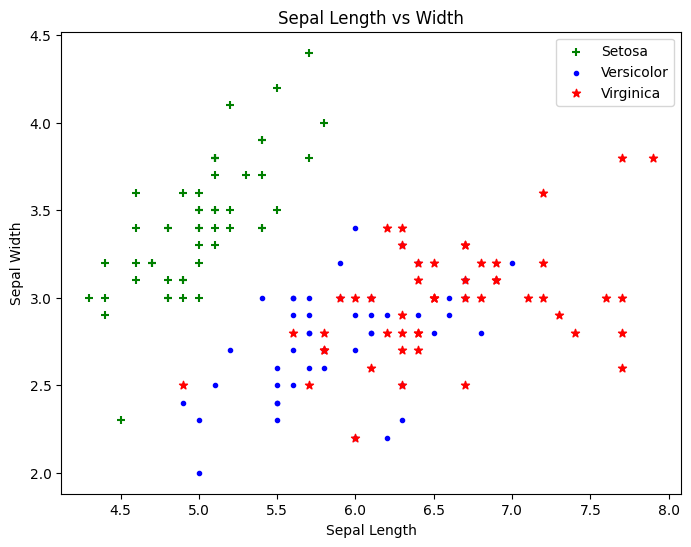

In [11]:
# Separate dataframes for each species for plotting
df0 = df[df.target == 0]
df1 = df[df.target == 1]
df2 = df[df.target == 2]

plt.figure(figsize=(8, 6))
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.scatter(df0['sepal length (cm)'], df0['sepal width (cm)'], color='green', marker='+', label='Setosa')
plt.scatter(df1['sepal length (cm)'], df1['sepal width (cm)'], color='blue', marker='.', label='Versicolor')
plt.scatter(df2['sepal length (cm)'], df2['sepal width (cm)'], color='red', marker='*', label='Virginica')
plt.legend()
plt.title('Sepal Length vs Width')
plt.show()

## 3. Train-Test Split
We split the data into features ($X$) and target ($y$), and then into training and testing sets.

In [12]:
X = df.drop(['target', 'flower_name'], axis='columns')
y = df.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 105
Testing set size: 45


## 4. K-Nearest Neighbors Classifier
We will use `KNeighborsClassifier` with $K=5$.

In [13]:
# Create KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

# Score the model
score = knn.score(X_test, y_test)
print(f"Model Accuracy (K=5): {score:.4f}")

Model Accuracy (K=5): 1.0000


## 5. Model Evaluation
Let's look at the Confusion Matrix to understand the misclassifications.

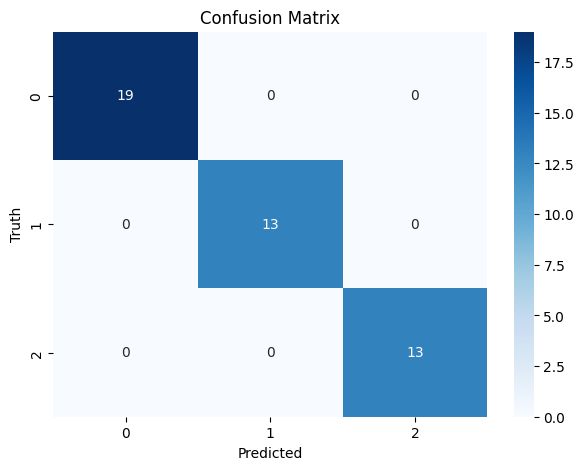

In [14]:
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()

In [15]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## 6. Discussion: Choosing K and Cross-Validation

### The Value of K
- **Small K**: A small value (e.g., K=1) makes the model complex and sensitive to noise (overfitting).
- **Large K**: A large value makes the model simple but might miss local patterns (underfitting).
- **K=5**: Often a good starting point.

### Cross-Validation
To find the optimal $K$, we can use **K-Fold Cross-Validation**. This technique splits the data into $K$ folds (not to be confused with the K in KNN) and trains/tests the model multiple times to get a robust estimate of performance. This helps in selecting hyperparameters that generalize well to unseen data.